# Эксперимент 5: LOBSTER backtest для NLCR

Этот ноутбук проверяет NLCR в более рыночной постановке, чем простой bid/ask sanity-check. Мы строим признаки из limit order book, обучаем несколько моделей краткосрочного прогноза, применяем `ols`, `wls`, `shr` reconciliation к прогнозу constrained-вектора и затем смотрим не только forecast accuracy, но и простой cost-aware trading backtest.

Цель здесь не получить production trading strategy, а проверить, помогает ли NLCR делать прогнозы более согласованными и полезными в финансовой задаче с реалистичными ограничениями: `spread = ask - bid`, `mid = (ask + bid)/2`, `relative_spread = spread / mid`, `imbalance = (bid_size - ask_size)/(bid_size + ask_size)`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.constraints import lobster_bid_ask_constraints
from src.metrics import compare_forecasts, mean_constraint_violation
from src.nlcr import reconcile_many
from src.stat_tests import paired_forecast_tests

RESULTS_DIR = PROJECT_ROOT / "results"
(RESULTS_DIR / "tables").mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "figures").mkdir(parents=True, exist_ok=True)

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "lobster" / "lobster_bid_ask_1level.parquet"
DATA_PATH

PosixPath('/Users/ilolss/HSE/nlcr-empirical-evaluation/data/processed/lobster/lobster_bid_ask_1level.parquet')

## Данные и ограничения

Используем подготовленный LOBSTER AAPL sample. Если `data/processed/lobster/lobster_bid_ask_1level.parquet` отсутствует, сначала запусти:

```bash
python scripts/download_data.py lobster
python scripts/prepare_data.py lobster --levels 1 --sample-every 20 --max-rows 2000
```

Для более тяжёлого эксперимента можно уменьшить `--sample-every`, увеличить `--max-rows`, или подготовить level 5/10 sample.

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing {DATA_PATH}. Run scripts/download_data.py lobster and scripts/prepare_data.py lobster first."
    )

data = pd.read_parquet(DATA_PATH).reset_index(drop=True)
levels = 1
tick_size = 0.01
constraints = lobster_bid_ask_constraints(levels=levels, tick_size=tick_size)
columns = constraints.names

data = data[[col for col in ["time", *columns] if col in data.columns]].copy()
print(data.shape)
data.head()

(2000, 9)


,time,ask_price_1,ask_size_1,bid_price_1,bid_size_1,spread,mid,relative_spread,imbalance
0,51529.676652,581.81,100.0,581.69,5.0,0.12,581.750,0.000206,-0.904762
1,51530.361380,581.71,5.0,581.63,34.0,0.08,581.670,0.000138,0.743590
2,51531.319148,581.81,119.0,581.66,134.0,0.15,581.735,0.000258,0.059289
3,51540.827930,581.80,54.0,581.67,124.0,0.13,581.735,0.000223,0.393258
4,51544.799196,581.77,107.0,581.67,94.0,0.10,581.720,0.000172,-0.064677


In [3]:
summary = data[columns].describe().T
summary["constraint_violation"] = [
    mean_constraint_violation(data[columns].iloc[[i]].to_numpy(), constraints)
    for i in range(min(len(data), len(columns)))
] + [np.nan] * max(0, len(summary) - min(len(data), len(columns)))
summary

,count,mean,std,min,25%,50%,75%,max,constraint_violation
ask_price_1,2000.0,579.649000,1.460605,577.510000,578.190000,579.700000,581.160000,582.170000,0.0
ask_size_1,2000.0,152.496500,191.827041,1.000000,100.000000,100.000000,200.000000,3000.000000,0.0
bid_price_1,2000.0,579.537810,1.442863,577.450000,578.080000,579.565000,581.042500,582.040000,0.0
bid_size_1,2000.0,334.446000,1342.345774,1.000000,100.000000,100.000000,200.000000,22063.000000,0.0
spread,2000.0,0.111190,0.058416,0.010000,0.070000,0.100000,0.150000,0.330000,0.0
mid,2000.0,579.593405,1.451468,577.485000,578.123750,579.637500,581.100000,582.105000,0.0
relative_spread,2000.0,0.000192,0.000101,0.000017,0.000120,0.000173,0.000259,0.000570,0.0
imbalance,2000.0,0.107355,0.526733,-0.995012,-0.333333,0.000000,0.533046,0.998335,0.0


## Feature engineering

Признаки используют только информацию, доступную в момент `t`: текущие top-of-book values, rolling microstructure features и лаги. Target — constrained-вектор через `HORIZON` шагов. Это позволяет сравнить прогнозы до/после NLCR как в обычной forecasting-задаче, а затем использовать predicted future mid для торгового сигнала.

In [4]:
HORIZON = 10
LAGS = [1, 2, 3, 5, 10, 20]
ROLLING_WINDOWS = [5, 20, 50]
MAX_TEST_ROWS = 200

lob = data.copy()
lob["microprice"] = (
    lob["ask_price_1"] * lob["bid_size_1"] + lob["bid_price_1"] * lob["ask_size_1"]
) / (lob["ask_size_1"] + lob["bid_size_1"])
lob["mid_return"] = lob["mid"].diff()
lob["log_mid_return"] = np.log(lob["mid"]).diff()
lob["spread_change"] = lob["spread"].diff()
lob["imbalance_change"] = lob["imbalance"].diff()

feature_cols = [
    "ask_price_1", "ask_size_1", "bid_price_1", "bid_size_1",
    "spread", "mid", "relative_spread", "imbalance", "microprice",
    "mid_return", "log_mid_return", "spread_change", "imbalance_change",
]

for col in ["mid", "spread", "relative_spread", "imbalance", "microprice", "mid_return"]:
    for lag in LAGS:
        lob[f"{col}_lag_{lag}"] = lob[col].shift(lag)
        feature_cols.append(f"{col}_lag_{lag}")

for window in ROLLING_WINDOWS:
    lob[f"mid_return_mean_{window}"] = lob["mid_return"].rolling(window).mean()
    lob[f"mid_return_vol_{window}"] = lob["mid_return"].rolling(window).std()
    lob[f"spread_mean_{window}"] = lob["spread"].rolling(window).mean()
    lob[f"imbalance_mean_{window}"] = lob["imbalance"].rolling(window).mean()
    feature_cols.extend([
        f"mid_return_mean_{window}", f"mid_return_vol_{window}",
        f"spread_mean_{window}", f"imbalance_mean_{window}",
    ])

for col in columns:
    lob[f"target_{col}"] = lob[col].shift(-HORIZON)

target_cols = [f"target_{col}" for col in columns]
selected_cols = list(dict.fromkeys(["time", *columns, *feature_cols, *target_cols]))
model_frame = lob[selected_cols].replace([np.inf, -np.inf], np.nan).dropna()
model_frame = model_frame.reset_index(drop=True)

print("model_frame", model_frame.shape)
model_frame[["time", "mid", "spread", "imbalance", *target_cols[:3]]].head()

model_frame (1940, 70)


,time,mid,spread,imbalance,target_ask_price_1,target_ask_size_1,target_bid_price_1
0,51693.080138,581.575,0.27,0.699717,581.42,60.0,581.33
1,51697.805307,581.525,0.11,0.333333,581.38,7.0,581.25
2,51706.075853,581.515,0.25,-0.333333,581.38,7.0,581.31
3,51706.083335,581.515,0.23,0.829268,581.39,7.0,581.32
4,51711.210477,581.505,0.17,-0.428571,581.44,2.0,581.33


## Chronological split

Используем train/calibration/test. Calibration нужен для оценки covariance forecast errors в `wls` и `shr`. Test не участвует ни в обучении, ни в оценке ковариации.

In [5]:
n = len(model_frame)
train_end = int(n * 0.60)
cal_end = int(n * 0.80)

train = model_frame.iloc[:train_end].copy()
cal = model_frame.iloc[train_end:cal_end].copy()
test = model_frame.iloc[cal_end:].copy()
if MAX_TEST_ROWS is not None and len(test) > MAX_TEST_ROWS:
    test = test.tail(MAX_TEST_ROWS).copy()

X_train = train[feature_cols]
y_train = train[target_cols].to_numpy(dtype=float)
X_cal = cal[feature_cols]
y_cal = cal[target_cols].to_numpy(dtype=float)
X_test = test[feature_cols]
y_test = test[target_cols].to_numpy(dtype=float)
current_test = test[columns].reset_index(drop=True)

split_summary = pd.DataFrame([
    {"split": "train", "rows": len(train), "start_time": train["time"].iloc[0] if "time" in train else np.nan, "end_time": train["time"].iloc[-1] if "time" in train else np.nan},
    {"split": "calibration", "rows": len(cal), "start_time": cal["time"].iloc[0] if "time" in cal else np.nan, "end_time": cal["time"].iloc[-1] if "time" in cal else np.nan},
    {"split": "test", "rows": len(test), "start_time": test["time"].iloc[0] if "time" in test else np.nan, "end_time": test["time"].iloc[-1] if "time" in test else np.nan},
])
split_summary

,split,rows,start_time,end_time
0,train,1164,51693.080138,56056.155325
1,calibration,388,56056.176211,56899.034379
2,test,200,57270.994249,57590.009424


## Модели

- `naive_state`: прогнозирует future constrained-vector текущим состоянием стакана.
- `ridge`: линейная модель с масштабированием признаков.
- `extra_trees`: нелинейный tree ensemble, часто сильный baseline для табличных microstructure features.
- `hist_gbr`: gradient boosting baseline через `MultiOutputRegressor`.

После прогноза каждой модели применяем NLCR methods: `none`, `ols`, `wls`, `shr`. `none` нужен как baseline до reconciliation.

In [6]:
models = {
    "naive_state": None,
    "ridge": make_pipeline(StandardScaler(), Ridge(alpha=5.0)),
    "extra_trees": ExtraTreesRegressor(
        n_estimators=120,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    ),
    "hist_gbr": MultiOutputRegressor(
        HistGradientBoostingRegressor(
            max_iter=120,
            learning_rate=0.05,
            max_leaf_nodes=16,
            l2_regularization=0.01,
            random_state=42,
        )
    ),
}

def sanitize_lob_forecast(values, tick_size=0.01):
    frame = pd.DataFrame(values, columns=columns).astype(float)
    frame["ask_price_1"] = frame["ask_price_1"].clip(lower=tick_size)
    frame["bid_price_1"] = frame["bid_price_1"].clip(lower=tick_size)
    frame["ask_size_1"] = frame["ask_size_1"].clip(lower=1.0)
    frame["bid_size_1"] = frame["bid_size_1"].clip(lower=1.0)
    frame["spread"] = frame["spread"].clip(lower=tick_size)
    frame["mid"] = frame["mid"].clip(lower=tick_size)
    frame["relative_spread"] = frame["relative_spread"].clip(lower=0.0)
    frame["imbalance"] = frame["imbalance"].clip(lower=-1.0, upper=1.0)
    return frame[columns].to_numpy(dtype=float)

predictions = {}
calibration_errors = {}

for model_name, model in models.items():
    if model is None:
        pred_cal = cal[columns].to_numpy(dtype=float)
        pred_test = current_test.to_numpy(dtype=float)
    else:
        model.fit(X_train, y_train)
        pred_cal = model.predict(X_cal)
        pred_test = model.predict(X_test)

    pred_cal = sanitize_lob_forecast(pred_cal, tick_size=tick_size)
    pred_test = sanitize_lob_forecast(pred_test, tick_size=tick_size)

    predictions[(model_name, "none")] = pd.DataFrame(pred_test, columns=columns)
    calibration_errors[model_name] = y_cal - pred_cal
    print(model_name, "pred_test", pred_test.shape)

naive_state pred_test (200, 8)
ridge pred_test (200, 8)


extra_trees pred_test (200, 8)


hist_gbr pred_test (200, 8)


In [7]:
for model_name in models:
    base_pred = predictions[(model_name, "none")]
    for method in ["ols", "wls", "shr"]:
        kwargs = {} if method == "ols" else {"errors": calibration_errors[model_name]}
        reconciled, failed = reconcile_many(
            base_pred,
            constraints,
            method=method,
            maxiter=300,
            **kwargs,
        )
        predictions[(model_name, method)] = reconciled
        print(model_name, method, "failed", len(failed))

naive_state ols failed 0


naive_state wls failed 0


naive_state shr failed 0


ridge ols failed 0


ridge wls failed 0


...

extra_trees wls failed 0


extra_trees shr failed 0


hist_gbr ols failed 3


hist_gbr wls failed 2


hist_gbr shr failed 2


## Forecast accuracy и constraint diagnostics

Сначала смотрим прямые forecasting-метрики по constrained-вектору и violation. Здесь `none` показывает качество модели до reconciliation, а `ols/wls/shr` — после NLCR.

In [8]:
forecast_rows = []
for (model_name, method), pred in predictions.items():
    metrics = compare_forecasts(y_test, predictions[(model_name, "none")], pred, constraints)
    row = metrics[metrics["forecast"] == "nlcr"].iloc[0].to_dict() if method != "none" else {
        "forecast": "base",
        "mae": metrics[metrics["forecast"] == "base"].iloc[0]["mae"],
        "rmse": metrics[metrics["forecast"] == "base"].iloc[0]["rmse"],
        "smape": metrics[metrics["forecast"] == "base"].iloc[0]["smape"],
        "constraint_violation": mean_constraint_violation(pred, constraints),
    }
    row.update({"model": model_name, "method": method})
    forecast_rows.append(row)

forecast_metrics = pd.DataFrame(forecast_rows)
forecast_metrics = forecast_metrics[["model", "method", "mae", "rmse", "smape", "constraint_violation"]]
forecast_metrics.to_csv(RESULTS_DIR / "tables" / "lobster_backtest_forecast_metrics.csv", index=False)
forecast_metrics.sort_values(["model", "rmse"])

,model,method,mae,rmse,smape,constraint_violation
2,extra_trees,none,48.923407,176.953315,0.620486,2.239255e-01
10,extra_trees,ols,48.924374,176.953315,0.559229,4.765639e-13
11,extra_trees,wls,48.904110,177.339323,0.600075,1.447351e-11
12,extra_trees,shr,48.953651,177.698143,0.602504,1.918911e-11
14,hist_gbr,wls,51.006763,192.082850,0.656058,1.259201e-11
15,hist_gbr,shr,51.006763,192.082850,0.656058,1.259201e-11
3,hist_gbr,none,60.241998,204.625061,0.776163,7.800746e-01
13,hist_gbr,ols,60.703177,205.937824,0.763534,1.147975e-11
0,naive_state,none,62.312964,228.947518,0.498995,0.000000e+00
4,naive_state,ols,62.312964,228.947518,0.498995,0.000000e+00


In [9]:
stat_rows = []
for model_name in models:
    base_pred = predictions[(model_name, "none")]
    for method in ["ols", "wls", "shr"]:
        tests = paired_forecast_tests(y_test, base_pred, predictions[(model_name, method)], n_bootstrap=1000)
        tests.insert(0, "model", model_name)
        tests.insert(1, "method", method)
        stat_rows.append(tests)

forecast_stat_tests = pd.concat(stat_rows, ignore_index=True)
forecast_stat_tests.to_csv(RESULTS_DIR / "tables" / "lobster_backtest_forecast_stat_tests.csv", index=False)
forecast_stat_tests[["model", "method", "metric", "relative_improvement_pct", "win_rate", "wilcoxon_p"]].head(18)

/Users/ilolss/HSE/nlcr-empirical-evaluation/src/stat_tests.py:19: RuntimeWarning: Mean of empty slice
  "mae": np.nanmean(np.abs(error), axis=1),
/Users/ilolss/HSE/nlcr-empirical-evaluation/src/stat_tests.py:20: RuntimeWarning: Mean of empty slice
  "rmse": np.sqrt(np.nanmean(error * error, axis=1)),
/Users/ilolss/HSE/nlcr-empirical-evaluation/src/stat_tests.py:21: RuntimeWarning: Mean of empty slice
  "smape": np.nanmean(


/Users/ilolss/HSE/nlcr-empirical-evaluation/src/stat_tests.py:19: RuntimeWarning: Mean of empty slice
  "mae": np.nanmean(np.abs(error), axis=1),
/Users/ilolss/HSE/nlcr-empirical-evaluation/src/stat_tests.py:20: RuntimeWarning: Mean of empty slice
  "rmse": np.sqrt(np.nanmean(error * error, axis=1)),
/Users/ilolss/HSE/nlcr-empirical-evaluation/src/stat_tests.py:21: RuntimeWarning: Mean of empty slice
  "smape": np.nanmean(
/Users/ilolss/HSE/nlcr-empirical-evaluation/src/stat_tests.py:19: RuntimeWarning: Mean of empty slice
  "mae": np.nanmean(np.abs(error), axis=1),
/Users/ilolss/HSE/nlcr-empirical-evaluation/src/stat_tests.py:20: RuntimeWarning: Mean of empty slice
  "rmse": np.sqrt(np.nanmean(error * error, axis=1)),
/Users/ilolss/HSE/nlcr-empirical-evaluation/src/stat_tests.py:21: RuntimeWarning: Mean of empty slice
  "smape": np.nanmean(


/Users/ilolss/HSE/nlcr-empirical-evaluation/src/stat_tests.py:19: RuntimeWarning: Mean of empty slice
  "mae": np.nanmean(np.abs(error), axis=1),
/Users/ilolss/HSE/nlcr-empirical-evaluation/src/stat_tests.py:20: RuntimeWarning: Mean of empty slice
  "rmse": np.sqrt(np.nanmean(error * error, axis=1)),
/Users/ilolss/HSE/nlcr-empirical-evaluation/src/stat_tests.py:21: RuntimeWarning: Mean of empty slice
  "smape": np.nanmean(


,model,method,metric,relative_improvement_pct,win_rate,wilcoxon_p
0,naive_state,ols,mae,0.000000e+00,NaN,1.000000e+00
1,naive_state,ols,rmse,0.000000e+00,NaN,1.000000e+00
2,naive_state,ols,smape,0.000000e+00,NaN,1.000000e+00
3,naive_state,wls,mae,-1.632218e-10,0.424242,1.000000e+00
4,naive_state,wls,rmse,-9.524996e-12,0.527950,1.000000e+00
5,naive_state,wls,smape,-9.134614e-01,0.429293,9.999999e-01
6,naive_state,shr,mae,-1.632218e-10,0.424242,1.000000e+00
7,naive_state,shr,rmse,-9.524996e-12,0.527950,1.000000e+00
8,naive_state,shr,smape,-9.134614e-01,0.429293,9.999999e-01
9,ridge,ols,mae,-2.627596e-02,0.360000,9.999889e-01


## Бэктест торговой стратегии с учетом издержек

Торговое правило намеренно простое:

- сигнал = прогнозируемая будущая mid-price - текущая mid-price;
- длинная позиция, если сигнал больше текущего спреда;
- короткая позиция, если сигнал меньше отрицательного текущего спреда;
- иначе позиция не открывается;
- издержки исполнения аппроксимируются половиной спреда сейчас плюс половиной спреда на горизонте прогноза.

Это консервативная оценка для исполнения через спред. Это не промышленный симулятор исполнения заявок, но она предотвращает самую распространенную ошибку: объявлять крошечные прогнозы mid-price прибыльными, игнорируя спред.

In [10]:
def backtest_from_prediction(pred: pd.DataFrame, current: pd.DataFrame, y_true_array: np.ndarray) -> pd.DataFrame:
    true = pd.DataFrame(y_true_array, columns=columns)
    current_mid = current["mid"].to_numpy(dtype=float)
    future_mid = true["mid"].to_numpy(dtype=float)
    pred_mid = pred["mid"].to_numpy(dtype=float)
    current_spread = current["spread"].to_numpy(dtype=float)
    future_spread = true["spread"].to_numpy(dtype=float)

    signal = pred_mid - current_mid
    threshold = current_spread
    position = np.where(signal > threshold, 1.0, np.where(signal < -threshold, -1.0, 0.0))
    gross_pnl = position * (future_mid - current_mid)
    crossing_cost = np.abs(position) * 0.5 * (current_spread + future_spread)
    net_pnl = gross_pnl - crossing_cost

    return pd.DataFrame(
        {
            "signal": signal,
            "position": position,
            "gross_pnl": gross_pnl,
            "cost": crossing_cost,
            "net_pnl": net_pnl,
            "realized_mid_move": future_mid - current_mid,
        }
    )


def summarize_backtest(path: pd.DataFrame) -> dict[str, float]:
    pnl = path["net_pnl"].to_numpy(dtype=float)
    trades = path["position"].to_numpy(dtype=float) != 0.0
    cumulative = np.cumsum(pnl)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    if np.nanstd(pnl) > 0:
        sharpe_like = np.sqrt(len(pnl)) * np.nanmean(pnl) / np.nanstd(pnl)
    else:
        sharpe_like = np.nan
    return {
        "n": len(path),
        "trades": int(np.sum(trades)),
        "trade_rate": float(np.mean(trades)),
        "mean_net_pnl": float(np.nanmean(pnl)),
        "total_net_pnl": float(np.nansum(pnl)),
        "hit_rate": float(np.mean(path.loc[trades, "net_pnl"] > 0.0)) if np.any(trades) else np.nan,
        "sharpe_like": float(sharpe_like),
        "max_drawdown": float(np.nanmin(drawdown)) if len(drawdown) else np.nan,
        "turnover": float(np.nansum(np.abs(path["position"].diff().fillna(path["position"])))),
    }

backtest_paths = {}
backtest_rows = []
for key, pred in predictions.items():
    path = backtest_from_prediction(pred, current_test, y_test)
    backtest_paths[key] = path
    row = summarize_backtest(path)
    row.update({"model": key[0], "method": key[1]})
    backtest_rows.append(row)

backtest_summary = pd.DataFrame(backtest_rows)
backtest_summary.to_csv(RESULTS_DIR / "tables" / "lobster_backtest_trading_summary.csv", index=False)
backtest_summary.sort_values("total_net_pnl", ascending=False)

,n,trades,trade_rate,mean_net_pnl,total_net_pnl,hit_rate,sharpe_like,max_drawdown,turnover,model,method
0,200,0,0.000,0.00000,0.00,NaN,NaN,0.00,0.0,naive_state,none
6,200,0,0.000,0.00000,0.00,NaN,NaN,0.00,0.0,naive_state,shr
5,200,0,0.000,0.00000,0.00,NaN,NaN,0.00,0.0,naive_state,wls
4,200,0,0.000,0.00000,0.00,NaN,NaN,0.00,0.0,naive_state,ols
1,200,43,0.215,-0.01120,-2.24,0.348837,-3.035598,-2.41,34.0,ridge,none
7,200,43,0.215,-0.01120,-2.24,0.348837,-3.035598,-2.41,34.0,ridge,ols
8,200,43,0.215,-0.01120,-2.24,0.348837,-3.035598,-2.41,34.0,ridge,wls
9,200,54,0.270,-0.02555,-5.11,0.166667,-5.590330,-5.11,44.0,ridge,shr
14,200,198,0.990,-0.07510,-15.02,0.176768,-10.946900,-14.88,5.0,hist_gbr,wls
15,200,198,0.990,-0.07510,-15.02,0.176768,-10.946900,-14.88,5.0,hist_gbr,shr


In [11]:
direction_rows = []
true_move = pd.DataFrame(y_test, columns=columns)["mid"].to_numpy() - current_test["mid"].to_numpy()
true_direction = np.sign(true_move)

for (model_name, method), pred in predictions.items():
    pred_move = pred["mid"].to_numpy() - current_test["mid"].to_numpy()
    pred_direction = np.sign(pred_move)
    active = pred_direction != 0
    direction_rows.append(
        {
            "model": model_name,
            "method": method,
            "direction_accuracy_all": float(np.mean(pred_direction == true_direction)),
            "direction_accuracy_active": float(np.mean(pred_direction[active] == true_direction[active])) if np.any(active) else np.nan,
            "active_rate": float(np.mean(active)),
            "corr_pred_realized_move": float(np.corrcoef(pred_move, true_move)[0, 1]) if np.std(pred_move) > 0 else np.nan,
        }
    )

direction_metrics = pd.DataFrame(direction_rows)
direction_metrics.to_csv(RESULTS_DIR / "tables" / "lobster_backtest_direction_metrics.csv", index=False)
direction_metrics.sort_values("corr_pred_realized_move", ascending=False)

,model,method,direction_accuracy_all,direction_accuracy_active,active_rate,corr_pred_realized_move
3,hist_gbr,none,0.355,0.355000,1.00,0.290313
12,extra_trees,shr,0.355,0.355000,1.00,0.284447
11,extra_trees,wls,0.355,0.355000,1.00,0.277716
2,extra_trees,none,0.355,0.355000,1.00,0.277716
10,extra_trees,ols,0.355,0.355000,1.00,0.277716
5,naive_state,wls,0.610,0.616162,0.99,0.162177
6,naive_state,shr,0.610,0.616162,0.99,0.162177
1,ridge,none,0.410,0.410000,1.00,0.017089
7,ridge,ols,0.410,0.410000,1.00,0.017089
8,ridge,wls,0.410,0.410000,1.00,0.017088


## Графики

Смотрим cumulative net PnL и constraint violation. Если NLCR полезен в market setting, он должен не только занулять violation, но и не разрушать signal quality; иногда WLS/SHR могут улучшить сигнал за счёт более разумной геометрии projection.

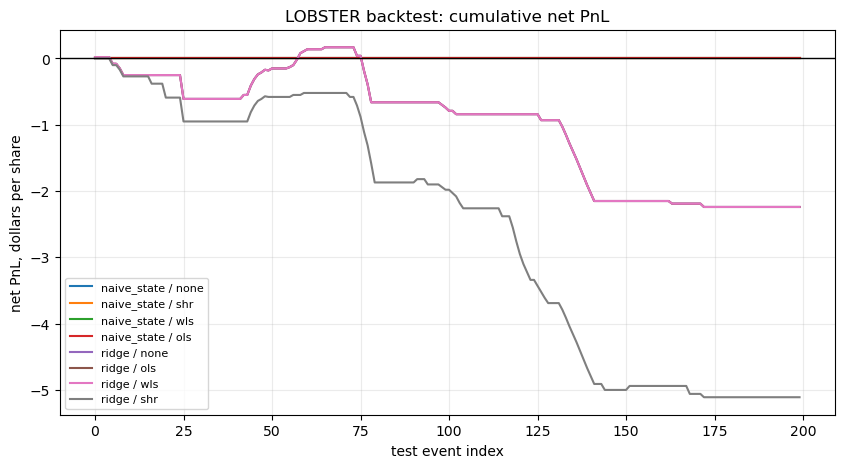

In [12]:
top = backtest_summary.sort_values("total_net_pnl", ascending=False).head(8)
fig, ax = plt.subplots(figsize=(10, 5))
for _, row in top.iterrows():
    key = (row["model"], row["method"])
    cumulative = backtest_paths[key]["net_pnl"].cumsum().to_numpy()
    ax.plot(cumulative, label=f"{key[0]} / {key[1]}")
ax.axhline(0.0, color="black", linewidth=1)
ax.set_title("LOBSTER backtest: cumulative net PnL")
ax.set_xlabel("test event index")
ax.set_ylabel("net PnL, dollars per share")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
fig.savefig(RESULTS_DIR / "figures" / "lobster_backtest_cumulative_pnl.png", dpi=200, bbox_inches="tight")
display(fig)
plt.close(fig)

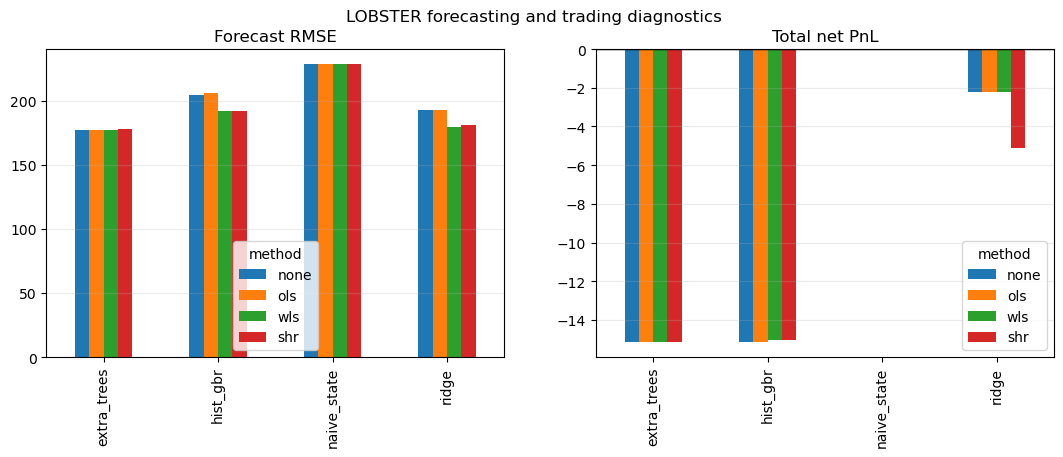

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pivot_rmse = forecast_metrics.pivot(index="model", columns="method", values="rmse")
pivot_rmse[[col for col in ["none", "ols", "wls", "shr"] if col in pivot_rmse.columns]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Forecast RMSE")
axes[0].set_xlabel("")
axes[0].grid(axis="y", alpha=0.25)

pivot_pnl = backtest_summary.pivot(index="model", columns="method", values="total_net_pnl")
pivot_pnl[[col for col in ["none", "ols", "wls", "shr"] if col in pivot_pnl.columns]].plot(kind="bar", ax=axes[1])
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set_title("Total net PnL")
axes[1].set_xlabel("")
axes[1].grid(axis="y", alpha=0.25)

fig.suptitle("LOBSTER forecasting and trading diagnostics")
fig.savefig(RESULTS_DIR / "figures" / "lobster_backtest_model_comparison.png", dpi=200, bbox_inches="tight")
display(fig)
plt.close(fig)

## Интерпретация

Этот backtest специально сделан консервативным: сигнал должен перекрыть текущий spread, а PnL штрафуется crossing cost. На маленьком однодневном sample нельзя делать утверждения о стабильной торговой прибыли. Зато можно проверить важный для NLCR вопрос: сохраняется ли польза reconciliation, когда прогноз используется в downstream financial decision.

Следующие улучшения для более серьёзного эксперимента:

- подготовить LOBSTER level 5 или level 10 и добавить depth features;
- перейти с event-stride sampling на 1s/5s clock-time bars;
- добавить walk-forward retraining вместо одного train/cal/test split;
- добавить transaction fees, latency и inventory limits;
- добавить DeepLOB-like модель как optional neural baseline.

## Выводы по результатам эксперимента

- NLCR надежно устраняет structural violations: например, у `ridge none` violation `0.419`, у `extra_trees none` `0.224`, у `hist_gbr none` `0.780`, а после reconciliation — порядка `1e-11`.
- По forecast accuracy NLCR особенно полезен для более слабых моделей: `ridge wls` снижает RMSE `192.94 -> 179.65`, `hist_gbr wls/shr` — `204.63 -> 192.08`.
- В cost-aware trading backtest положительного net PnL не получено: лучшие торгующие варианты остаются отрицательными (`ridge wls`: `-2.24`, `extra_trees`: около `-15.15`).
- Следовательно, NLCR не является самостоятельной alpha-моделью; его практическая роль — post-processing/risk-control слой, который улучшает согласованность и иногда forecast quality уже существующего прогноза.